In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm
from dataset import DiffusionDataset, get_dataloader, sin_1d
from utils.diffusion import Diffusion, cosine_schedule
from models.mlp import ScoreModel
from models.train import train_score_mlp

# Generate data

In [35]:
dataset = DiffusionDataset(dataset_name='sin_1d', n_samples=3000, seed=42, x_normalise=False, y_normalise=False)
train_loader, test_loader, val_loader = get_dataloader(dataset, batch_size=32, train_ratio=0.8, val_ratio=0.1, shuffle=True, seed=42)
batch = next(iter(train_loader))
batch['X'].shape

torch.Size([32, 1])

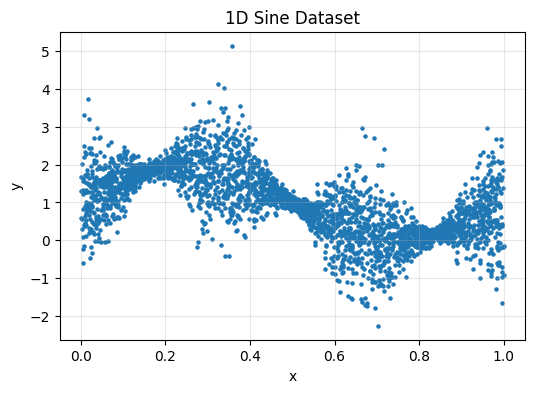

In [36]:
plt.figure(figsize=(6, 4))
plt.grid(alpha=0.3)
plt.xlabel('x')
plt.ylabel('y')
plt.title('1D Sine Dataset')
plt.scatter(dataset.X, dataset.y, s=5)

# Diffusion process

torch.Size([1001])
torch.Size([1001])
torch.Size([1001])
tensor(1.) tensor(0.0010)
tensor(0.) tensor(0.9990)
tensor(1.) tensor(1.9110e-15)


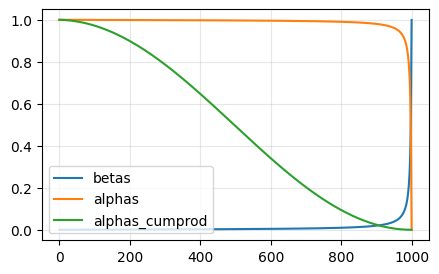

In [7]:
# check the schedules
betas, alphas, alphas_cumprod = cosine_schedule(1000)
print(betas.shape)
print(alphas.shape)
print(alphas_cumprod.shape)

print(alphas[0], alphas[-1])
print(betas[0], betas[-1])
print(alphas_cumprod[0], alphas_cumprod[-1])

plt.figure(figsize=(5, 3))
plt.grid(alpha=0.3)
plt.plot(betas, label='betas')
plt.plot(alphas, label='alphas')
plt.plot(alphas_cumprod, label='alphas_cumprod')
plt.legend(loc='lower left')

torch.Size([1000])
torch.Size([1000])
torch.Size([1000])


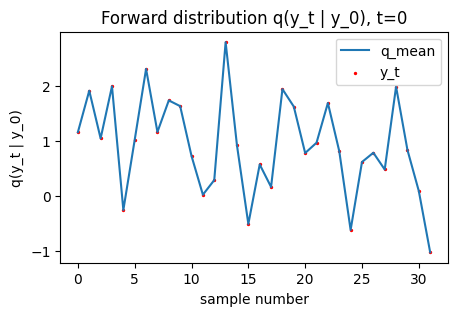

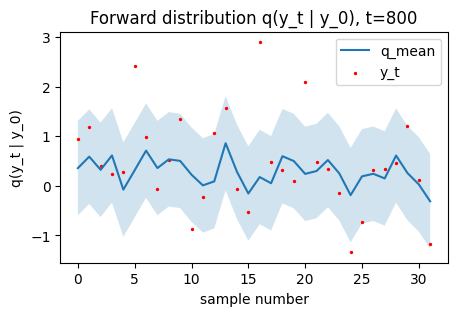

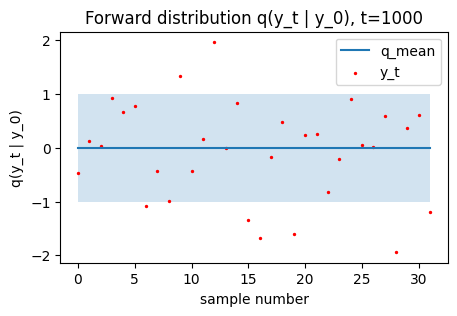

torch.Size([32])
torch.Size([32])


In [8]:
d = Diffusion(T=1000)
print(d.posterior_variance.shape)
print(d.posterior_mean_coef1.shape)
print(d.posterior_mean_coef2.shape)

y0 = batch['y']

plt.figure(figsize=(5, 3))
t = 0
q_mean, q_var = d.forward_q(y0, t)
# sample y_t from q(y_t | y_0)
noise = torch.randn_like(y0)
y_t = d.q_sample(y0, t, noise)
plt.title(f'Forward distribution q(y_t | y_0), t={t}')
plt.xlabel('sample number')
plt.ylabel('q(y_t | y_0)')
plt.plot(q_mean, label='q_mean')
# fill between standard deviation
plt.fill_between(range(len(q_mean)), q_mean - q_var**0.5, q_mean + q_var**0.5, alpha=0.2)
plt.scatter(range(len(y_t)), y_t, s=2, c='r', label='y_t')
plt.legend()
plt.show()

plt.figure(figsize=(5, 3))
t = 800
q_mean, q_var = d.forward_q(y0, t)
# sample y_t from q(y_t | y_0)
noise = torch.randn_like(y0)
y_t = d.q_sample(y0, t, noise)
plt.title(f'Forward distribution q(y_t | y_0), t={t}')
plt.xlabel('sample number')
plt.ylabel('q(y_t | y_0)')
plt.plot(q_mean, label='q_mean')
# fill between standard deviation
plt.fill_between(range(len(q_mean)), q_mean - q_var**0.5, q_mean + q_var**0.5, alpha=0.2)
plt.scatter(range(len(y_t)), y_t, s=2, c='r', label='y_t')
plt.legend()
plt.show()

plt.figure(figsize=(5, 3))
t = 1000
q_mean, q_var = d.forward_q(y0, t)
# sample y_t from q(y_t | y_0)
noise = torch.randn_like(y0)
y_t = d.q_sample(y0, t, noise)
plt.title(f'Forward distribution q(y_t | y_0), t={t}')
plt.xlabel('sample number')
plt.ylabel('q(y_t | y_0)')
plt.plot(q_mean, label='q_mean')
# fill between standard deviation
plt.fill_between(range(len(q_mean)), q_mean - q_var**0.5, q_mean + q_var**0.5, alpha=0.2)
plt.scatter(range(len(y_t)), y_t, s=2, c='r', label='y_t')
plt.legend()
plt.show()

print(q_mean.shape)
print(q_var.shape)


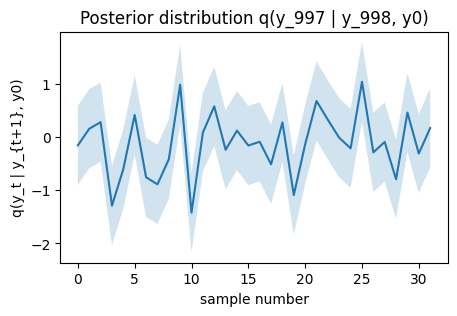

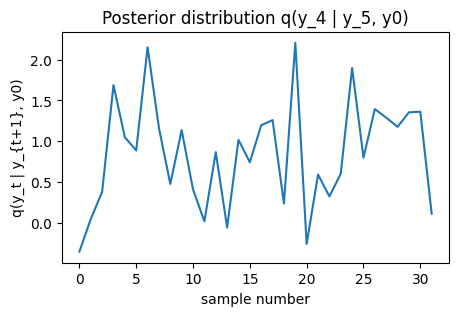

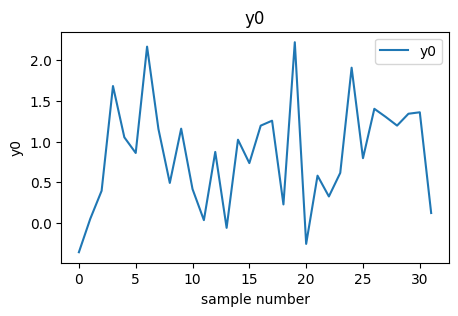

In [11]:
# sample y_T from q(y_T | y_0)
t = 998
q_mean, q_var = d.forward_q(y0, t) # get the forward distribution q(y_t | y_0)
y_t = q_mean + torch.randn_like(q_mean) * torch.sqrt(q_var) # sample y_T from q(y_t | y_0)
q_posterior_mean, q_posterior_var = d.reverse_q(y0, y_t, t-1)
plt.figure(figsize=(5, 3))
plt.title(f'Posterior distribution q(y_{t-1} | y_{t}, y0)')
plt.xlabel('sample number')
plt.ylabel('q(y_t | y_{t+1}, y0)')
plt.plot(q_posterior_mean, label='q_posterior_mean')
# fill between standard deviation
plt.fill_between(range(len(q_posterior_mean)), q_posterior_mean - q_posterior_var**0.5, q_posterior_mean + q_posterior_var**0.5, alpha=0.2)

t = 5
q_mean, q_var = d.forward_q(y0, t) # get the forward distribution q(y_t | y_0)
y_t = q_mean + torch.randn_like(q_mean) * torch.sqrt(q_var) # sample y_T from q(y_t | y_0)
q_posterior_mean, q_posterior_var = d.reverse_q(y0, y_t, t-1)
plt.figure(figsize=(5, 3))
plt.title(f'Posterior distribution q(y_{t-1} | y_{t}, y0)')
plt.xlabel('sample number')
plt.ylabel('q(y_t | y_{t+1}, y0)')
plt.plot(q_posterior_mean, label='q_posterior_mean')
# fill between standard deviation
plt.fill_between(range(len(q_posterior_mean)), q_posterior_mean - q_posterior_var**0.5, q_posterior_mean + q_posterior_var**0.5, alpha=0.2)

# plot the y0
plt.figure(figsize=(5, 3))
plt.title('y0')
plt.xlabel('sample number')
plt.ylabel('y0')
plt.plot(y0, label='y0')
plt.legend()
plt.show()


# Training

In [37]:
model, train_loss, val_loss = train_score_mlp(train_loader, val_loader, hidden_dims=[64, 64, 128], time_embed_dim=64, epoch_update=10, num_epochs=200, time_steps=1000, learning_rate=1e-4, device_type='cpu', save_path=None)

Epoch 0/200, Train Loss: 0.6257, Val Loss: 0.4681
Epoch 10/200, Train Loss: 0.3956, Val Loss: 0.3603
Epoch 20/200, Train Loss: 0.3732, Val Loss: 0.3714
Epoch 30/200, Train Loss: 0.3660, Val Loss: 0.3523
Epoch 40/200, Train Loss: 0.3583, Val Loss: 0.2907
Epoch 50/200, Train Loss: 0.3751, Val Loss: 0.3162
Epoch 60/200, Train Loss: 0.3441, Val Loss: 0.3389
Epoch 70/200, Train Loss: 0.3266, Val Loss: 0.3627
Epoch 80/200, Train Loss: 0.3424, Val Loss: 0.3087
Epoch 90/200, Train Loss: 0.3564, Val Loss: 0.3123
Epoch 100/200, Train Loss: 0.3296, Val Loss: 0.3443
Epoch 110/200, Train Loss: 0.3457, Val Loss: 0.3650
Epoch 120/200, Train Loss: 0.3185, Val Loss: 0.3382
Epoch 130/200, Train Loss: 0.3720, Val Loss: 0.3925
Epoch 140/200, Train Loss: 0.3730, Val Loss: 0.3386
Epoch 150/200, Train Loss: 0.3421, Val Loss: 0.3982
Epoch 160/200, Train Loss: 0.3496, Val Loss: 0.2461
Epoch 170/200, Train Loss: 0.3146, Val Loss: 0.2553
Epoch 180/200, Train Loss: 0.3465, Val Loss: 0.3005
Epoch 190/200, Train Lo

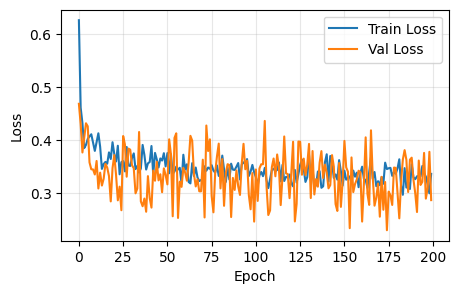

In [38]:
plt.figure(figsize=(5, 3))
plt.grid(alpha=0.3)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.legend()
plt.show()

In [39]:
def sample_from_model(model, location, num_samples, device):
    y_t = torch.randn(num_samples).to(device)
    x = torch.ones_like(y_t) * location
    diffusion = Diffusion(T=1000, device=device)
    
    for t in range(999, -1, -1):
        t_tensor = torch.ones_like(y_t) * (t+1)
        score = model(x, y_t, t_tensor)
        y_t = (1/torch.sqrt(diffusion.alphas[t+1])) * (y_t - ((1-diffusion.alphas[t+1])/torch.sqrt(1-diffusion.alphas_cumprod[t+1])) * score)
        y_t += torch.randn_like(y_t) * torch.sqrt(diffusion.betas[t])
        y_t = torch.clamp(y_t, min=-5.0, max=5.0) # y_t is still normalised
    return y_t

In [48]:
X.shape

torch.Size([32, 1])

In [49]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
locations = []
predictions = []
true_values = []
T=1000
diffusion = Diffusion(T=1000, device=device)
with tqdm(total=len(test_loader)) as pbar:
    for batch in test_loader:
        X = batch['X'].to(device)[:,0]
        y_0 = batch['y'].to(device)[:,0]
        y_t = torch.randn_like(y_0, device=device)
        
        for t in range(T-1, -1, -1):
            t_tensor = torch.ones_like(y_t) * (t+1)
            score = model(X, y_t, t_tensor)
            y_t = (1/torch.sqrt(diffusion.alphas[t+1])) * (y_t - ((1-diffusion.alphas[t+1])/torch.sqrt(1-diffusion.alphas_cumprod[t+1])) * score)
            y_t += torch.randn_like(y_t) * torch.sqrt(diffusion.betas[t])
            y_t = torch.clamp(y_t, min=-5.0, max=5.0)
        predictions.append(y_t.detach().cpu().numpy())
        true_values.append(y_0.detach().cpu().numpy())
        locations.append(X.detach().cpu().numpy())
        pbar.update(1)

locations = np.concatenate(locations, axis=0)
predictions = np.concatenate(predictions, axis=0)
true_values = np.concatenate(true_values, axis=0)
rmse = np.sqrt(np.mean((predictions - true_values)**2))
print(f"RMSE: {rmse}")

100%|██████████| 10/10 [00:03<00:00,  2.67it/s]

RMSE: 0.730701744556427


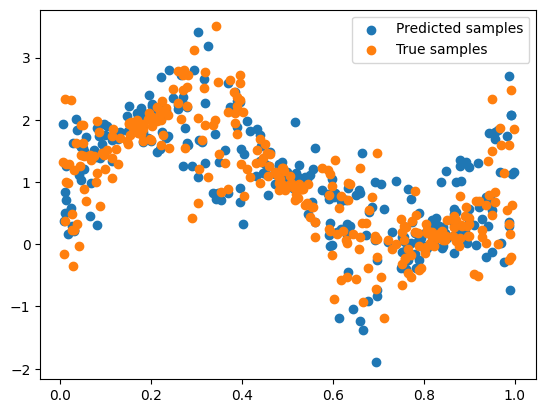

In [51]:
plt.scatter(locations, predictions, label='Predicted samples')
plt.scatter(locations, true_values, label='True samples')
plt.legend()
plt.show()

In [43]:
num_locations = 200
num_samples = 50
locations = torch.linspace(0, 1, num_locations)
results = np.zeros((num_locations,num_samples))
device = torch.device('cpu')

with tqdm(range(len(locations))) as pbar:
    for i, location in enumerate(locations):
        results[i] = sample_from_model(model, location, num_samples, device).detach().numpy()
        pbar.update(1)

# results = results * y_std + y_mean

100%|██████████| 200/200 [01:25<00:00,  2.34it/s]


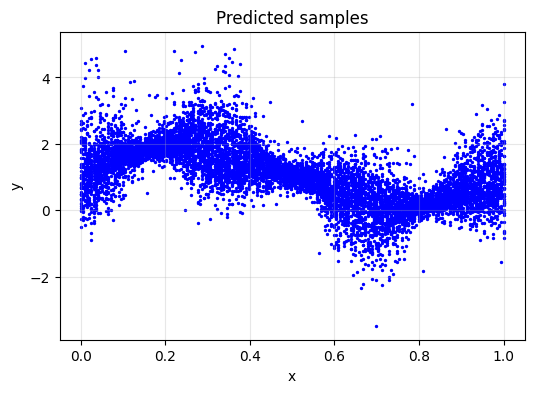

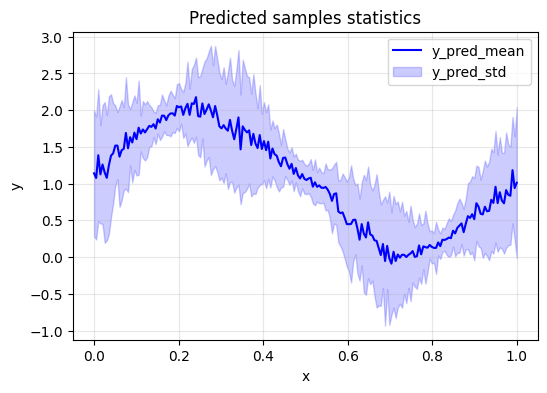

In [45]:
plt.figure(figsize=(6, 4))
plt.grid(alpha=0.3)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Predicted samples')
for i in range(results.shape[0]):
    plt.scatter(locations[i]*torch.ones(num_samples), results[i], s=2, c='b', label='y_t')
# plt.ylim(-5, 5)
# calculate the mean and std of the predicted samples
plt.figure(figsize=(6, 4))
plt.grid(alpha=0.3)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Predicted samples statistics')
y_pred_mean = np.mean(results, axis=1)
# get the variance of the predicted samples
y_pred_std = np.std(results, axis=1)
# plot the mean and std of the predicted samples
plt.plot(locations, y_pred_mean, label='y_pred_mean', c='b')
plt.fill_between(locations, y_pred_mean - y_pred_std, y_pred_mean + y_pred_std, alpha=0.2, label='y_pred_std', color='b')
plt.legend()

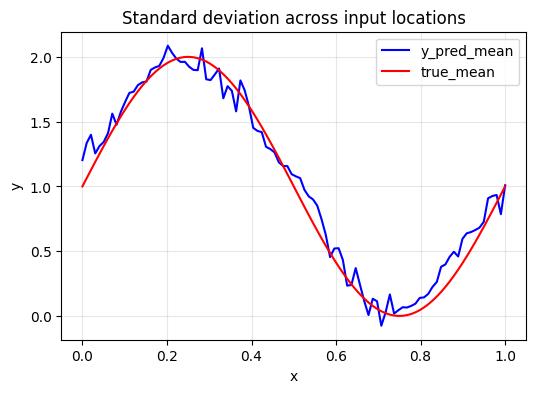

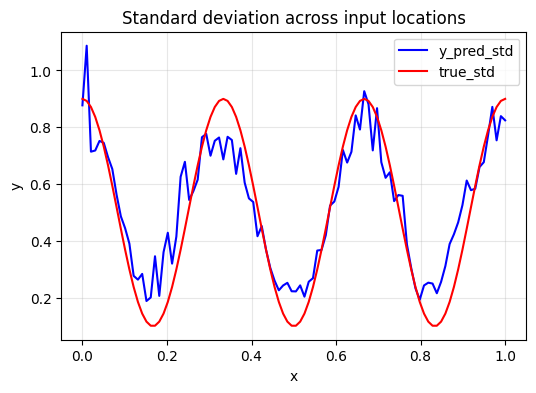

In [ ]:
# plot the standard deviation across input locations
plt.figure(figsize=(6, 4))
plt.grid(alpha=0.3)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Standard deviation across input locations')
plt.plot(locations, y_pred_mean, label='y_pred_mean', color='b')
# plot the true mean
plt.plot(locations, 1 + np.sin(2 * np.pi * locations), label='true_mean', color='r')
plt.legend()

# plot the standard deviation across input locations
plt.figure(figsize=(6, 4))
plt.grid(alpha=0.3)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Standard deviation across input locations')
plt.plot(locations, y_pred_std, label='y_pred_std', color='b')
# plot the true standard deviation
plt.plot(locations, 0.5 + 0.4 * np.cos(6 * np.pi * locations), label='true_std', color='r')
# plt.ylim(-1, 1.5)
plt.legend()

# Graveyard

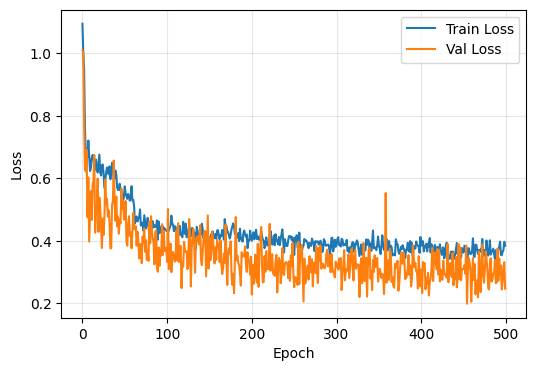

In [5]:
plt.figure(figsize=(6, 4))
plt.grid(alpha=0.3)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.legend()
plt.show()

In [7]:
num_locations = 200
x_locations = torch.linspace(0, 1, num_locations)
num_samples = 20
d = Diffusion(T=1000)
results = torch.zeros(num_locations,num_samples)

model.eval()
with torch.no_grad():
    with tqdm(range(len(x_locations))) as pbar:
        for i, location in enumerate(x_locations):
            x = torch.ones(num_samples) * location
            yt = torch.randn_like(x)
            for t in range(999,-1,-1):
                t_tensor = torch.ones(num_samples) * t
                score = model(x, yt, t_tensor)

                yt = (1/torch.sqrt(d.alphas[t])) * (yt - ((1-d.alphas[t+1])/torch.sqrt(1-d.alphas_cumprod[t+1])) * score)
                yt += torch.randn_like(yt) * torch.sqrt(d.betas[t+1])
            results[i] = yt
            pbar.update(1)

100%|██████████| 200/200 [00:20<00:00,  9.75it/s]


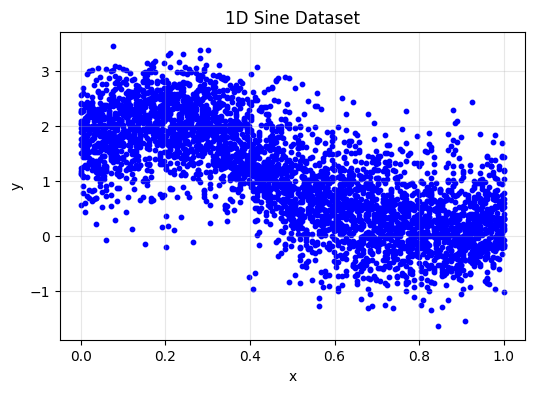

In [8]:
plt.figure(figsize=(6, 4))
plt.grid(alpha=0.3)
plt.xlabel('x')
plt.ylabel('y')
plt.title('1D Sine Dataset')
for i in range(results.shape[1]):
    plt.scatter(x_locations, results[:, i], s=10, c='b')
plt.show()


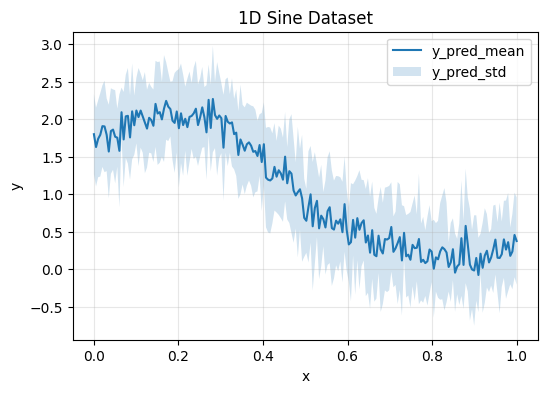

In [9]:
# calculate the mean of the y_pred
y_pred_mean = torch.mean(results, dim=1)
# calculate the std of the y_pred
y_pred_std = torch.std(results, dim=1)
# plot the y_pred
plt.figure(figsize=(6, 4))
plt.grid(alpha=0.3)
plt.xlabel('x')
plt.ylabel('y')
plt.title('1D Sine Dataset')
plt.plot(x_locations, y_pred_mean, label='y_pred_mean')
plt.fill_between(x_locations, y_pred_mean - y_pred_std, y_pred_mean + y_pred_std, alpha=0.2, label='y_pred_std')
plt.legend()
plt.show()